# dsQTL benchmark 7

Redo of the dsQTL panel from `AIB_CSHL_figures.ipynb` (same models, same scoring), with
the five Borzoi arms added:

| file | what it is |
|---|---|
| `borzoi_dsqtl_pretrained_1288.npy` | pretrained Borzoi, human target 1288 = `DNASE:GM12878` (ENCFF093VXI) |
| `borzoi_dsqtl_pretrained_1345.npy` | pretrained Borzoi, human target 1345 = `DNASE:GM12878` (ENCFF915DFR) |
| `borzoi_dsqtl_lorav2.npy` | Borzoi finetuned on GM12878, LoRA (v2) |
| `borzoi_dsqtl_trunk.npy` | Borzoi finetuned on GM12878, trunk finetune |
| `borzoi_dsqtl_scratch.npy` | Borzoi architecture trained from scratch on GM12878 |

Borzoi predictions are `(17506, 6144, 2)` -- 6144 bins of 32 bp (196608 bp) with the last
axis ref/alt, so they get the same centre crop as Enformer, expressed in bp rather than
bins (see `CENTER_BP` below).

In [1]:
#let's load this in and compare
%matplotlib inline

from sklearn.metrics import roc_curve, precision_recall_curve, auc
import pandas as pd
import numpy as np
from scipy.spatial.distance import jensenshannon
import matplotlib.pyplot as plt
import zarr

DSQTL_DIR = '/data1/lesliec/sarthak/data/joint_playground/dsQTL'


def predict_snp_effect_scores(ref_prob_preds, alt_prob_preds):
    '''
    Predicts variant effect scores based on model predictions.

    Arguments::
       ref_logcount_preds: log count predictions at the reference allele with size (N,)
       alt_logcount_preds: log count predictions at the alternate alele with size (N,)
       ref_prob_preds: profile probability predictions at the reference allele with size (N,outputlen). outputlen depends on the model.
       alt_prob_preds:  profile probability predictions at the alternate allele with size (N,outputlen). outputlen depends on the model.
    
    Returns:
        log_counts_diff: difference in log count predictions of alternate and reference allele (N,)
        log_probs_diff_abs_sum: Sum of absolute difference in log probability prediction of alternate and reference allele per base. (N,)
        probs_jsd_diff: Jensenshannon distance between probability predictions of alternate and reference allele (N,)
    '''
    # log_counts_diff = np.mean(alt_prob_preds, axis=1) - np.mean(ref_prob_preds, axis=1) #model doesn't have count prediction head, so it's really bad!
    # log_counts_diff = alt_count_preds - ref_count_preds
    log_probs_diff_abs_sum =  np.sum(np.abs(np.log(alt_prob_preds) -  np.log(ref_prob_preds)),axis=1)
    probs_jsd_diff = np.array([jensenshannon(x,y) for x,y in zip(alt_prob_preds, ref_prob_preds)])
    # integrative_effect_size = log_probs_diff_abs_sum * probs_jsd_diff
    logfc = np.log2(ref_prob_preds.mean(1) / alt_prob_preds.mean(1))
    integrative_effect_size = logfc * probs_jsd_diff
    integrative_effect_size_2 = log_probs_diff_abs_sum * probs_jsd_diff

    return logfc, log_probs_diff_abs_sum, probs_jsd_diff, integrative_effect_size, integrative_effect_size_2


def softmax(x, temp=1):
    norm_x = x - np.mean(x, axis=1, keepdims=True)
    return np.exp(temp*norm_x)/np.sum(np.exp(temp*norm_x), axis=1, keepdims=True)


def predict_snp_effect_scores_bpnet(ref_prob_preds, alt_prob_preds, ref_count_preds, alt_count_preds):
    '''
    Predicts variant effect scores based on model predictions.

    Arguments::
       ref_logcount_preds: log count predictions at the reference allele with size (N,)
       alt_logcount_preds: log count predictions at the alternate alele with size (N,)
       ref_prob_preds: profile probability predictions at the reference allele with size (N,outputlen). outputlen depends on the model.
       alt_prob_preds:  profile probability predictions at the alternate allele with size (N,outputlen). outputlen depends on the model.
    
    Returns:
        log_counts_diff: difference in log count predictions of alternate and reference allele (N,)
        log_probs_diff_abs_sum: Sum of absolute difference in log probability prediction of alternate and reference allele per base. (N,)
        probs_jsd_diff: Jensenshannon distance between probability predictions of alternate and reference allele (N,)
    '''
    
    print(ref_prob_preds.shape, alt_prob_preds.shape, ref_count_preds.shape, alt_count_preds.shape)
    # log_counts_diff = np.mean(alt_prob_preds, axis=1) - np.mean(ref_prob_preds, axis=1) #model doesn't have count prediction head, so it's really bad!
    # log_counts_diff = alt_count_preds - ref_count_preds
    log_probs_diff_abs_sum =  np.sum(np.abs(np.log(alt_prob_preds) -  np.log(ref_prob_preds)),axis=1)
    #and account for nan
    log_probs_diff_abs_sum[np.isnan(log_probs_diff_abs_sum)] = 0
    # probs_jsd_diff = np.array([jensenshannon(softmax(x),softmax(y)) for x,y in zip(alt_prob_preds, ref_prob_preds)])
    probs_jsd_diff = np.squeeze([jensenshannon(x, y, base=2.0)
                     for x,y in zip(softmax(alt_prob_preds),
                                    softmax(ref_prob_preds))])
    # integrative_effect_size = log_probs_diff_abs_sum * probs_jsd_diff
    logfc = np.log2(ref_count_preds/alt_count_preds)[:,0]
    integrative_effect_size = logfc * probs_jsd_diff
    integrative_effect_size_2 = log_probs_diff_abs_sum * probs_jsd_diff

    return logfc, log_probs_diff_abs_sum, probs_jsd_diff, integrative_effect_size, integrative_effect_size_2


qtls = pd.read_csv(f'{DSQTL_DIR}/filtered_dsqtls.txt', sep='\t')
labels = qtls['label'].to_numpy()
print(qtls.shape, labels.sum(), 'positives')

(17506, 19) -16636 positives


In [2]:
# ── loading ────────────────────────────────────────────────────────────────────
# Same dispatch as AIB_CSHL_figures, plus a Borzoi branch. Enformer keeps its
# hard-coded [440:456] crop (16 bins x 128 bp = 2048 bp around the variant); Borzoi is
# cropped to the *same genomic width* -- 2048 bp / 32 bp = 64 bins around bin 3072 --
# so the two are scored over the same window. Borzoi files are 1.7 GB float64, so they
# are memmapped and only the crop is materialised.

CENTER_BP = 2048          # width of the window scored around the variant
BORZOI_BIN = 32           # bp per Borzoi bin
BORZOI_NBINS = 6144

BORZOI_FILES = [
    'borzoi_dsqtl_pretrained_1288.npy',
    'borzoi_dsqtl_pretrained_1345.npy',
    'borzoi_dsqtl_lorav2.npy',
    'borzoi_dsqtl_trunk.npy',
    'borzoi_dsqtl_scratch.npy',
]
BORZOI_TITLES = [
    'Borzoi pretrained (DNase GM12878, 1288)',
    'Borzoi pretrained (DNase GM12878, 1345)',
    'Borzoi LoRA (GM12878)',
    'Borzoi trunk finetune (GM12878)',
    'Borzoi from scratch (GM12878)',
]


def borzoi_crop(center_bp=CENTER_BP):
    """Bin slice covering the central `center_bp` bp of a Borzoi prediction."""
    half = int(round(center_bp / BORZOI_BIN / 2))
    mid = BORZOI_NBINS // 2
    return slice(mid - half, mid + half)


def load_out(file, enformer_center=False, center_bp=CENTER_BP):
    """(logfc, log_probs_diff_abs_sum, JSD, IED1, IED2) for one prediction file."""
    if file.endswith('.npz'):
        pred_cbp = np.load('/data1/lesliec/sarthak/data/joint_playground/chrombpnet/GM12878_Tcellbias/var_prds.npz')
        return predict_snp_effect_scores_bpnet(
            pred_cbp['profile'][:, :, 0],
            pred_cbp['profile'][:, :, 1],
            pred_cbp['counts'][:, :, 0],
            pred_cbp['counts'][:, :, 1]
        )
    if file.endswith('zarr'):
        eqtl_data = zarr.open(f'{DSQTL_DIR}/{file}')
        return predict_snp_effect_scores(eqtl_data[:, :, 0], eqtl_data[:, :, 1])
    if 'borzoi' in file:
        eqtl_data = np.load(f'{DSQTL_DIR}/{file}', mmap_mode='r')
        eqtl_data = np.asarray(eqtl_data[:, borzoi_crop(center_bp), :])
        return predict_snp_effect_scores(eqtl_data[:, :, 0], eqtl_data[:, :, 1])
    eqtl_data = np.load(f'{DSQTL_DIR}/{file}')
    if enformer_center and 'enformer' in file:
        eqtl_data = eqtl_data[:, 440:456, :]
    return predict_snp_effect_scores(eqtl_data[:, :, 0], eqtl_data[:, :, 1])


METRIC_INDEX_MAP = {
    'logfc': 0,
    'log_probs_diff_abs_sum': 1,
    'JSD': 2,
    'IED1': 3,
    'IED2': 4,
}

print(borzoi_crop(), 'bins ->', borzoi_crop().stop - borzoi_crop().start, 'bins of', BORZOI_BIN, 'bp')

slice(3040, 3104, None) bins -> 64 bins of 32 bp


In [3]:
def plot_selected_metric(files, labels, metric_name='logfc', sort_legend_by_auc=False,
                         enformer_center=False, titles=None, title=None, colors=None,
                         center_bp=CENTER_BP, figsize=(7, 6)):
    """
    Plots publication-ready Precision-Recall curves for selected SNP effect metrics.
    """
    assert metric_name in METRIC_INDEX_MAP, f"Invalid metric: {metric_name}"
    metric_idx = METRIC_INDEX_MAP[metric_name]

    # Set up the figure
    plt.figure(figsize=figsize)
    plt.rcParams.update({'font.size': 11})

    line_width = 2

    if colors is None:
        colors = ['blue', 'green', 'brown', 'gray', 'purple', 'pink', 'olive', 'cyan',
                  '#E07B39', '#8B5CF6', '#59A89C', '#D65F5F', '#4878CF']

    legend_entries = []

    # Plot each model's PR curve
    for i, file in enumerate(files):
        out = load_out(file, enformer_center=enformer_center, center_bp=center_bp)

        if i == 0:
            non_zero_mask = (out[0] != 0)

        scores = np.abs(out[metric_idx])[non_zero_mask]
        precision, recall, _ = precision_recall_curve(labels[non_zero_mask], scores)
        pr_auc = auc(recall, precision)

        line, = plt.plot(
            recall,
            precision,
            label=titles[i] if titles else file,
            color=colors[i % len(colors)],
            linewidth=line_width
        )
        legend_entries.append((pr_auc, line, f"{titles[i] if titles else file} (AUC={pr_auc:.3f})"))

    # Format title and labels
    plt.title(
        title or f'Precision–Recall Curve ({metric_name.upper()})',
        fontsize=14,
        fontweight='bold',
        pad=10
    )
    plt.xlabel('Recall', fontsize=15)
    plt.ylabel('Precision', fontsize=15)

    # Grid for readability
    plt.grid(axis='both', linestyle='--', alpha=0.5)

    # Sort legend by AUC if requested
    if sort_legend_by_auc:
        legend_entries.sort(key=lambda x: x[0], reverse=True)
    handles = [entry[1] for entry in legend_entries]
    labels_sorted = [entry[2] for entry in legend_entries]

    # Legend styling
    plt.legend(
        handles,
        labels_sorted,
        title='Model (AUC)',
        title_fontsize=11,
        fontsize=9,
        loc='upper right',
        frameon=False
    )

    # Tight layout and display
    plt.tight_layout()
    plt.show()


def compute_auc_scores(files, labels, metric_name='logfc', enformer_center=False,
                       titles=None, center_bp=CENTER_BP):
    assert metric_name in METRIC_INDEX_MAP, f"Invalid metric: {metric_name}"
    metric_idx = METRIC_INDEX_MAP[metric_name]

    results = []
    first_real_file_seen = False

    for i, file in enumerate(files):
        label = titles[i] if titles else str(file)

        # pre-computed scalar (e.g. the ChromBPNet ATAC number): nothing to load
        if isinstance(file, (int, float)):
            results.append((file, label))
            continue

        out = load_out(file, enformer_center=enformer_center, center_bp=center_bp)

        if not first_real_file_seen:
            non_zero_mask = (out[0] != 0)
            first_real_file_seen = True

        scores = np.abs(out[metric_idx])[non_zero_mask]
        precision, recall, _ = precision_recall_curve(labels[non_zero_mask], scores)
        pr_auc = auc(recall, precision)
        results.append((pr_auc, label))

    return results  # list of (auc_score, label)


def plot_auc_bar(
    results, colors=None, title=None,
    sort_descending=True, figsize=(10, 5), bar_width=0.55
):
    """
    Arguments:
        results: list of (auc_score, label) as returned by compute_auc_scores
        colors:  list of colors, one per entry
    """
    default_colors = [
        '#4878CF', '#D65F5F', '#6ACC65', '#B47CC7',
        '#C4AD66', '#77BEDB', '#F28E2B', '#59A89C',
    ]
    if colors is None:
        colors = default_colors

    full_entries = [(auc, label, colors[i % len(colors)]) for i, (auc, label) in enumerate(results)]

    if sort_descending:
        full_entries.sort(key=lambda x: x[0], reverse=True)

    auc_scores, bar_labels, bar_colors = zip(*full_entries)

    fig, ax = plt.subplots(figsize=figsize)
    fig.patch.set_facecolor('white')
    ax.set_facecolor('white')

    x = np.arange(len(bar_labels))
    bars = ax.bar(x, auc_scores, width=bar_width,
                  color=bar_colors, edgecolor='white', linewidth=0.8, zorder=3)

    ax.yaxis.grid(True, linestyle=':', linewidth=0.7, color='#DDDDDD', zorder=0)
    ax.set_axisbelow(True)

    y_max = max(auc_scores)
    y_min = max(0, min(auc_scores) * 0.92)
    for bar, val in zip(bars, auc_scores):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + y_max * 0.015,
            f'{val:.3f}',
            ha='center', va='bottom',
            fontsize=10.5, fontweight='bold', color='#222222'
        )

    ax.set_ylim(y_min, y_max * 1.13)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.2f}'))
    ax.set_ylabel('PR-AUC', fontsize=12, color='#444444', labelpad=10)
    ax.tick_params(axis='y', labelsize=10, colors='#555555', length=0)
    ax.set_xticks(x)
    ax.set_xticklabels(bar_labels, rotation=35, ha='right', fontsize=10.5, color='#222222')
    ax.tick_params(axis='x', length=0)

    for spine in ['top', 'right', 'left']:
        ax.spines[spine].set_visible(False)
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.spines['bottom'].set_linewidth(0.8)
    ax.axhline(y_min, color='#CCCCCC', linewidth=0.8)

    ax.set_title(
        title or 'PR-AUC Comparison',
        fontsize=13, fontweight='bold', color='#111111', pad=16, loc='left'
    )

    plt.tight_layout()
    plt.show()

## 1. The original panel, reproduced

Exactly the model set and ordering from the dsQTL section of `AIB_CSHL_figures.ipynb`.

(17506, 1000) (17506, 1000) (17506, 1) (17506, 1)


/tmp/ipykernel_3589778/2986873567.py:65: RuntimeWarning: invalid value encountered in log
  log_probs_diff_abs_sum =  np.sum(np.abs(np.log(alt_prob_preds) -  np.log(ref_prob_preds)),axis=1)


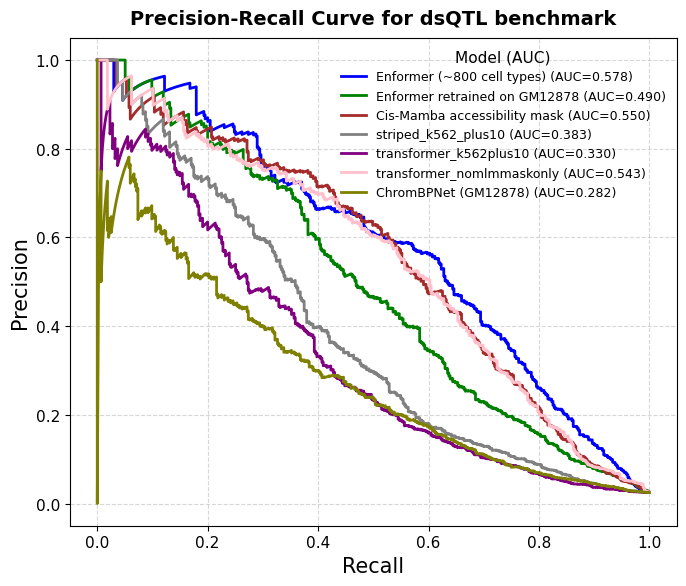

In [4]:
files = ['enformer_dsqtl.npy', 'enformer_dsqtl_retrained-dsqtl.npy', 'nomlm_maskonly.npy', 'striped_16000steps.npy', 'transformer_k562plus10.npy', 'transformer_nomlmmaskonly.npy', '.npz']
titles = ['Enformer (~800 cell types)', 'Enformer retrained on GM12878', 'Cis-Mamba accessibility mask', 'striped_k562_plus10', 'transformer_k562plus10', 'transformer_nomlmmaskonly',
                     'ChromBPNet (GM12878)']
plot_selected_metric(files, labels, metric_name='logfc', sort_legend_by_auc=False, enformer_center=True, titles=titles, title='Precision-Recall Curve for dsQTL benchmark')

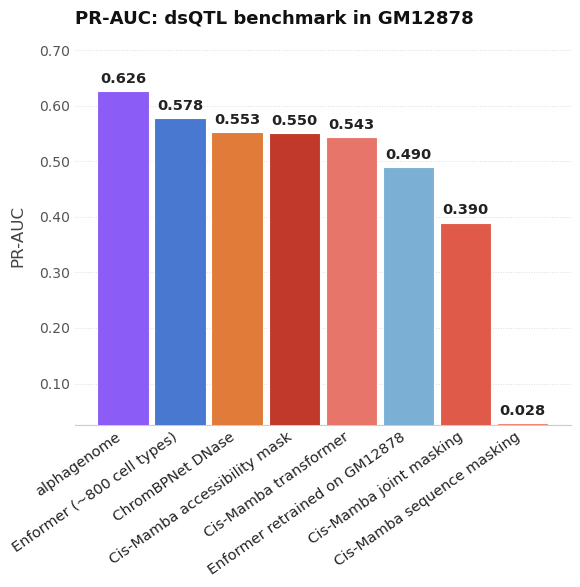

In [5]:
colors = [
    '#4878CF',  # Enformer (~800 cell types)        — blue
    '#7BAFD4',  # Enformer retrained on GM12878      — light blue

    '#C0392B',  # Cis-Mamba accessibility mask       — dark red
    '#E05A4A',  # Cis-Mamba joint masking            — medium red
    '#F08070',  # Cis-Mamba sequence masking         — light red
    '#E8756A',  # Cis-Mamba transformer              — salmon red

    '#8B5CF6',  # AlphaGenome                        — purple

    '#E07B39',  # ChromBPNet DNase                   — dark orange
    '#F4A95A',  # ChromBPNet ATAC                    — light orange
]
files = ['enformer_dsqtl.npy', 'enformer_dsqtl_retrained-dsqtl.npy', 'nomlm_maskonly.npy', 'base_dsqtl_mask_1000.npy', 'gm12878_noacc_.npy', 'transformer_nomlmmaskonly.npy', 'alphagenome_dsqtl.zarr', 0.553]
titles = ['Enformer (~800 cell types)', 'Enformer retrained on GM12878', 'Cis-Mamba accessibility mask', 'Cis-Mamba joint masking', 'Cis-Mamba sequence masking', 'Cis-Mamba transformer', 'alphagenome',
                     'ChromBPNet DNase', 'ChromBPNet ATAC']
results = compute_auc_scores(files, labels, metric_name='logfc', enformer_center=True, titles=titles)
plot_auc_bar(results,
    colors=colors,
    title='PR-AUC: dsQTL benchmark in GM12878',
    sort_descending=True,
    figsize=(6, 6),
    bar_width=0.9,
)

## 2. Same plot, with the five Borzoi arms added

Borzoi entries go after the originals so the non-zero mask is still taken from
`enformer_dsqtl.npy` (first entry), exactly as before -- every model is scored on the
same subset of variants.

In [6]:
# NOTE: the original `files`/`titles` above are copied verbatim from AIB_CSHL_figures and
# are mismatched -- 8 files vs 9 titles, so the trailing 'ChromBPNet ATAC' is never used
# and the 0.553 scalar is the bar labelled 'ChromBPNet DNase'. Slice to len(files) before
# appending Borzoi, or every Borzoi label lands on the wrong bar.
files_borzoi = list(files) + BORZOI_FILES
titles_borzoi = titles[:len(files)] + BORZOI_TITLES

colors_borzoi = colors[:len(files)] + [
    '#1B7837',  # Borzoi pretrained 1288             — dark green
    '#5AAE61',  # Borzoi pretrained 1345             — medium green
    '#2C7FB8',  # Borzoi LoRA                        — dark teal-blue
    '#41B6C4',  # Borzoi trunk                       — teal
    '#7FCDBB',  # Borzoi scratch                     — light teal
]
assert len(files_borzoi) == len(titles_borzoi) == len(colors_borzoi)

results_borzoi = compute_auc_scores(files_borzoi, labels, metric_name='logfc',
                                    enformer_center=True, titles=titles_borzoi)
for a, l in sorted(results_borzoi, reverse=True):
    print(f'{a:.4f}  {l}')

0.6258  alphagenome
0.5782  Enformer (~800 cell types)
0.5530  ChromBPNet DNase
0.5503  Cis-Mamba accessibility mask
0.5466  Borzoi LoRA (GM12878)
0.5432  Cis-Mamba transformer
0.5379  Borzoi pretrained (DNase GM12878, 1288)
0.5348  Borzoi trunk finetune (GM12878)
0.5022  Borzoi pretrained (DNase GM12878, 1345)
0.4899  Enformer retrained on GM12878
0.3895  Cis-Mamba joint masking
0.3786  Borzoi from scratch (GM12878)
0.0281  Cis-Mamba sequence masking


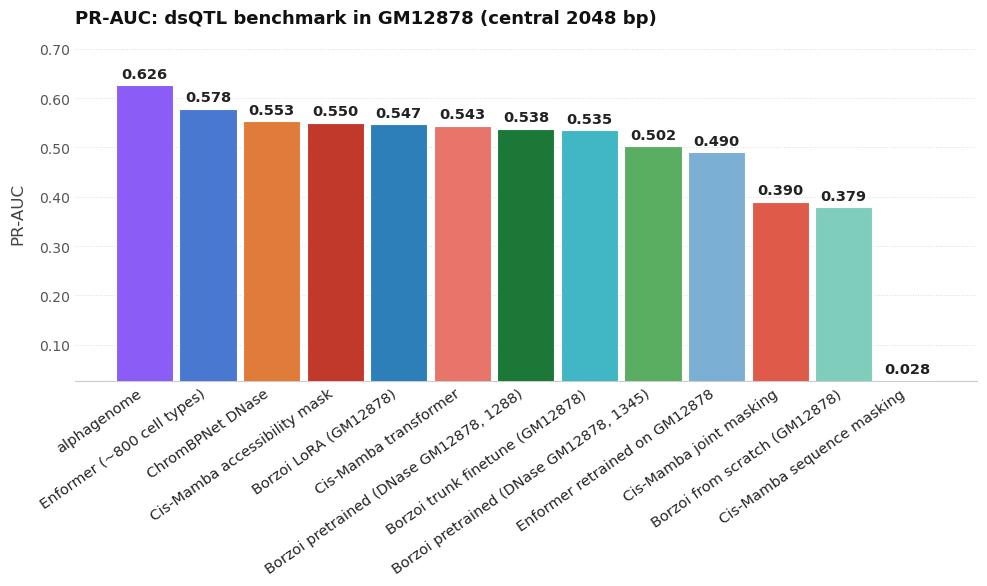

In [7]:
plot_auc_bar(results_borzoi,
    colors=colors_borzoi,
    title=f'PR-AUC: dsQTL benchmark in GM12878 (central {CENTER_BP} bp)',
    sort_descending=True,
    figsize=(10, 6),
    bar_width=0.9,
)

### PR curves with Borzoi

Dropping the scalar ChromBPNet-ATAC entry (no curve to draw for it) and the alphagenome
zarr is kept -- everything here loads a real prediction file.

(17506, 1000) (17506, 1000) (17506, 1) (17506, 1)


/tmp/ipykernel_3589778/2986873567.py:65: RuntimeWarning: invalid value encountered in log
  log_probs_diff_abs_sum =  np.sum(np.abs(np.log(alt_prob_preds) -  np.log(ref_prob_preds)),axis=1)


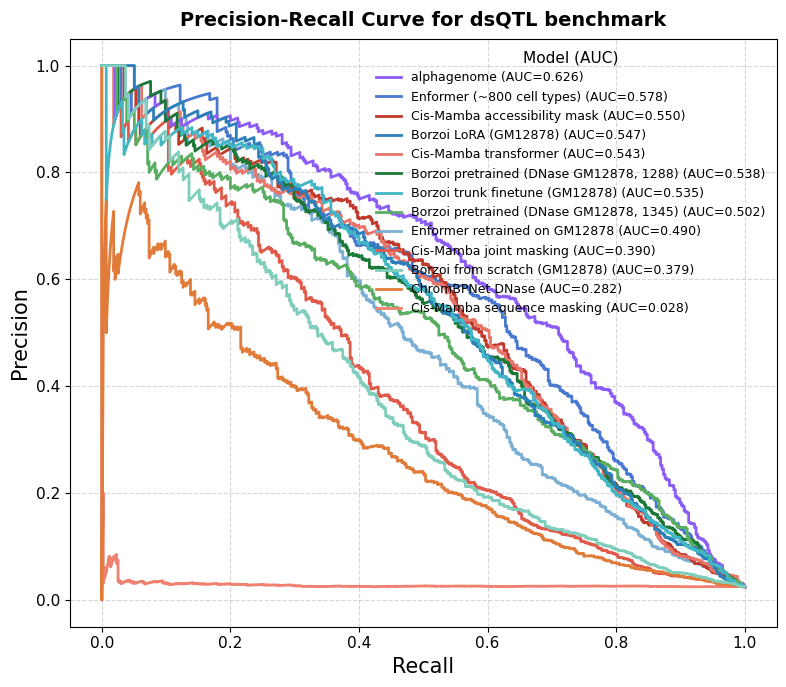

In [8]:
files_pr = ['enformer_dsqtl.npy', 'enformer_dsqtl_retrained-dsqtl.npy', 'nomlm_maskonly.npy',
            'base_dsqtl_mask_1000.npy', 'gm12878_noacc_.npy', 'transformer_nomlmmaskonly.npy',
            'alphagenome_dsqtl.zarr', '.npz'] + BORZOI_FILES
titles_pr = ['Enformer (~800 cell types)', 'Enformer retrained on GM12878', 'Cis-Mamba accessibility mask',
             'Cis-Mamba joint masking', 'Cis-Mamba sequence masking', 'Cis-Mamba transformer',
             'alphagenome', 'ChromBPNet DNase'] + BORZOI_TITLES
colors_pr = colors[:8] + colors_borzoi[-5:]
assert len(files_pr) == len(titles_pr) == len(colors_pr)

plot_selected_metric(files_pr, labels, metric_name='logfc', sort_legend_by_auc=True,
                     enformer_center=True, titles=titles_pr, colors=colors_pr,
                     title='Precision-Recall Curve for dsQTL benchmark',
                     figsize=(8, 7))

## 3. How much does the Borzoi crop width matter?

The 2048 bp window above is inherited from Enformer's `[440:456]`. Borzoi's 32 bp bins let
us score a much tighter window, so sweep it: 256 bp (8 bins) up to the full 196608 bp
(6144 bins). Run this before trusting the ranking above -- if Borzoi's PR-AUC moves a lot
with the window, the comparison to Enformer is window-limited rather than model-limited.

In [9]:
sweep_bp = [256, 512, 1024, 2048, 4096, 8192, BORZOI_NBINS * BORZOI_BIN]

# non-zero mask from enformer, same as everywhere else
mask_ref = load_out('enformer_dsqtl.npy', enformer_center=True)
non_zero_mask = (mask_ref[0] != 0)

sweep = {}
for f, t in zip(BORZOI_FILES, BORZOI_TITLES):
    row = []
    for bp in sweep_bp:
        out = load_out(f, center_bp=bp)
        scores = np.abs(out[0])[non_zero_mask]
        precision, recall, _ = precision_recall_curve(labels[non_zero_mask], scores)
        row.append(auc(recall, precision))
    sweep[t] = row
    print(t, ' '.join(f'{v:.3f}' for v in row))

sweep_df = pd.DataFrame(sweep, index=[f'{bp} bp' for bp in sweep_bp]).T
sweep_df

Borzoi pretrained (DNase GM12878, 1288) 0.527 0.544 0.548 0.538 0.522 0.503 0.350


Borzoi pretrained (DNase GM12878, 1345) 0.545 0.543 0.529 0.502 0.476 0.448 0.289


Borzoi LoRA (GM12878) 0.545 0.554 0.557 0.547 0.528 0.508 0.380


Borzoi trunk finetune (GM12878) 0.542 0.549 0.546 0.535 0.515 0.492 0.328


Borzoi from scratch (GM12878) 0.397 0.401 0.394 0.379 0.370 0.351 0.262


,256 bp,512 bp,1024 bp,2048 bp,4096 bp,8192 bp,196608 bp
"Borzoi pretrained (DNase GM12878, 1288)",0.527205,0.543838,0.548212,0.537869,0.522040,0.502947,0.350398
"Borzoi pretrained (DNase GM12878, 1345)",0.544654,0.542792,0.528723,0.502168,0.475828,0.448267,0.288818
Borzoi LoRA (GM12878),0.544795,0.553923,0.557242,0.546645,0.528334,0.507721,0.380290
Borzoi trunk finetune (GM12878),0.541752,0.549038,0.546325,0.534837,0.515399,0.491874,0.327532
Borzoi from scratch (GM12878),0.397163,0.400810,0.393950,0.378649,0.369848,0.351238,0.262179


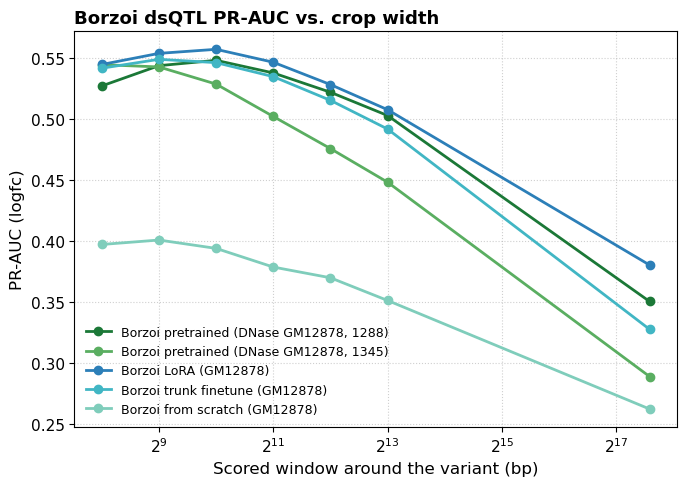

In [10]:
fig, ax = plt.subplots(figsize=(7, 5))
for (t, row), c in zip(sweep.items(), colors_borzoi[-5:]):
    ax.plot(sweep_bp, row, marker='o', label=t, color=c, linewidth=2)
ax.set_xscale('log', base=2)
ax.set_xlabel('Scored window around the variant (bp)', fontsize=12)
ax.set_ylabel('PR-AUC (logfc)', fontsize=12)
ax.set_title('Borzoi dsQTL PR-AUC vs. crop width', fontsize=13, fontweight='bold', loc='left')
ax.grid(linestyle=':', alpha=0.6)
ax.legend(fontsize=9, frameon=False)
plt.tight_layout()
plt.show()